# N-Scaling: BASS vs Fixed-Basis Fidelity Ratio

Tests whether the adaptive-basis advantage grows with system size N.

**Two regimes:**

- **Adaptive k** (k = 2^(N-1)): budget grows with N — tests whether basis adaptation
  helps even as the state has room to breathe.
- **Fixed k** (k = 8192): budget fixed — tests true compression pressure regime.

**Bands:** p10–p90 (outermost) · IQR · CI-95 for geometric mean (innermost).


In [ ]:
import sys, json, numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path


def find_repo_root(start=None):
    start = (
        __import__("pathlib").Path.cwd()
        if start is None
        else __import__("pathlib").Path(start).resolve()
    )
    for c in (start, *start.parents):
        if (c / "src").is_dir() and (c / "requirements.txt").exists():
            return c
    raise RuntimeError("Repo root not found")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

THIS_DIR = REPO_ROOT / "tests"
FIGURE_DIR = THIS_DIR / "figures"
DATA_DIR = THIS_DIR / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

from src.experimentation.runner import (
    make_brickwork,
    make_haar,
    make_rfim,
    run_n_scaling_full,
    trial_stats,
    add_ci_bands,
    print_nscaling_table,
)
from src.visualization.style import mplstyle, polish_axes, save_figure
from matplotlib.lines import Line2D

mplstyle(dpi=180)
mpl.rcParams.update(
    {
        "font.size": 8.0,
        "axes.labelsize": 8.0,
        "xtick.labelsize": 7.0,
        "ytick.labelsize": 7.0,
        "legend.fontsize": 6.8,
        "lines.linewidth": 1.35,
        "lines.markersize": 3.5,
        "axes.linewidth": 0.8,
    }
)

In [ ]:
N_VALUES = [10, 12, 14, 16, 18, 20]
N_TRIALS = 100
SEED_BASE = 20260520
FIXED_K = 8192
BASS_KW = dict(optimize_every=5, buffer_factor=1)
FORCE_RERUN = True

CIRCUIT_FAMILIES = {
    "RFIM (W=2)": {
        "color": "#1C875C",
        "factory": lambda N, rng: make_rfim(N, rng, layers=5, W=2.0, dt=0.2),
    },
    "Brickwork L=5": {
        "color": "#0C5DA5",
        "factory": lambda N, rng: make_brickwork(N, depth=5, rng=rng),
    },
    "Haar L=3": {
        "color": "#E87722",
        "factory": lambda N, rng: make_haar(N, depth=3, rng=rng),
    },
}

In [3]:
# ── Adaptive-k benchmark ──────────────────────────────────────────────────────
_npz_adap = DATA_DIR / "nscaling_adaptive_k.npz"
_meta_adap = DATA_DIR / "nscaling_adaptive_k_meta.json"
_expected = {
    "N_values": N_VALUES,
    "n_trials": N_TRIALS,
    "k_mode": "adaptive_2^(N-1)",
    "seed_base": SEED_BASE,
}

adap_results = {}

if _npz_adap.exists() and _meta_adap.exists() and not FORCE_RERUN:
    stored = json.loads(_meta_adap.read_text())
    if stored.get("N_values") == N_VALUES and stored.get("n_trials") == N_TRIALS:
        raw = dict(np.load(_npz_adap, allow_pickle=False))
        for label in CIRCUIT_FAMILIES:
            safe = label.replace(" ", "_").replace("=", "eq").replace("/", "")
            res = {
                "N_values": N_VALUES,
                "k_values": [int(2 ** (N - 1)) for N in N_VALUES],
                "f_fixed": raw[f"{safe}_f_fixed"],
                "f_bass": raw[f"{safe}_f_bass"],
                "pr_fixed": raw[f"{safe}_pr_fixed"],
                "pr_bass": raw[f"{safe}_pr_bass"],
            }
            res["stats"] = {
                N: {
                    "f_fixed": trial_stats(res["f_fixed"][:, ni], n_boot=2000),
                    "f_bass": trial_stats(res["f_bass"][:, ni], n_boot=2000),
                    "pr_fixed": trial_stats(res["pr_fixed"][:, ni], n_boot=2000),
                    "pr_bass": trial_stats(res["pr_bass"][:, ni], n_boot=2000),
                    "ratio": trial_stats(
                        res["f_bass"][:, ni]
                        / np.maximum(res["f_fixed"][:, ni], 1e-300),
                        n_boot=2000,
                    ),
                }
                for ni, N in enumerate(N_VALUES)
            }
            adap_results[label] = res
        print(f"Loaded adaptive-k cache: {_npz_adap}")

if not adap_results:
    save_arrs = {}
    for label, fam in CIRCUIT_FAMILIES.items():
        print(f"\n[{label}] adaptive-k sweep")
        res = run_n_scaling_full(
            fam["factory"],
            N_VALUES,
            k_fn=lambda N: int(2 ** (N - 1)),
            n_trials=N_TRIALS,
            seed_base=SEED_BASE,
            bass_kwargs=BASS_KW,
            verbose=True,
            n_boot=2000,
        )
        safe = label.replace(" ", "_").replace("=", "eq").replace("/", "")
        save_arrs[f"{safe}_f_fixed"] = res["f_fixed"]
        save_arrs[f"{safe}_f_bass"] = res["f_bass"]
        save_arrs[f"{safe}_pr_fixed"] = res["pr_fixed"]
        save_arrs[f"{safe}_pr_bass"] = res["pr_bass"]
        adap_results[label] = res
    np.savez_compressed(_npz_adap, **save_arrs)
    _meta_adap.write_text(json.dumps(_expected, indent=2))
    print(f"Saved {_npz_adap}")

print("\n--- Adaptive-k scaling table ---")
print_nscaling_table(adap_results, title="Adaptive-k (k = 2^(N-1))")


[RFIM (W=2)] adaptive-k sweep
  N=10 k=512: ratio_gm=1.024x  win=64%
  N=12 k=2048: ratio_gm=1.006x  win=43%
  N=14 k=8192: ratio_gm=1.004x  win=53%
  N=16 k=32768: ratio_gm=1.000x  win=43%
  N=18 k=131072: ratio_gm=1.000x  win=37%
  N=20 k=524288: ratio_gm=1.000x  win=32%

[Brickwork L=5] adaptive-k sweep
  N=10 k=512: ratio_gm=1.138x  win=86%
  N=12 k=2048: ratio_gm=1.061x  win=72%
  N=14 k=8192: ratio_gm=1.024x  win=62%
  N=16 k=32768: ratio_gm=1.010x  win=47%
  N=18 k=131072: ratio_gm=1.009x  win=51%
  N=20 k=524288: ratio_gm=0.999x  win=39%

[Haar L=3] adaptive-k sweep
  N=10 k=512: ratio_gm=1.066x  win=72%
  N=12 k=2048: ratio_gm=1.047x  win=78%
  N=14 k=8192: ratio_gm=1.006x  win=46%
  N=16 k=32768: ratio_gm=1.005x  win=39%
  N=18 k=131072: ratio_gm=0.999x  win=28%
  N=20 k=524288: ratio_gm=1.000x  win=41%
Saved c:\Users\karti\pyth\BASS code\tests\results\nscaling_adaptive_k.npz

--- Adaptive-k scaling table ---

Adaptive-k (k = 2^(N-1))
Family                  N       k  F_fix

In [4]:
# ── Fixed-k benchmark ─────────────────────────────────────────────────────────
_npz_fix = DATA_DIR / "nscaling_fixed_k.npz"
_meta_fix = DATA_DIR / "nscaling_fixed_k_meta.json"
_expected_fix = {
    "N_values": N_VALUES,
    "n_trials": N_TRIALS,
    "fixed_k": FIXED_K,
    "seed_base": SEED_BASE,
}

fix_results = {}

if _npz_fix.exists() and _meta_fix.exists() and not FORCE_RERUN:
    stored = json.loads(_meta_fix.read_text())
    if (
        stored.get("N_values") == N_VALUES
        and stored.get("n_trials") == N_TRIALS
        and stored.get("fixed_k") == FIXED_K
    ):
        raw = dict(np.load(_npz_fix, allow_pickle=False))
        for label in CIRCUIT_FAMILIES:
            safe = label.replace(" ", "_").replace("=", "eq").replace("/", "")
            res = {
                "N_values": N_VALUES,
                "k_values": [FIXED_K] * len(N_VALUES),
                "f_fixed": raw[f"{safe}_f_fixed"],
                "f_bass": raw[f"{safe}_f_bass"],
                "pr_fixed": raw[f"{safe}_pr_fixed"],
                "pr_bass": raw[f"{safe}_pr_bass"],
            }
            res["stats"] = {
                N: {
                    "f_fixed": trial_stats(res["f_fixed"][:, ni], n_boot=2000),
                    "f_bass": trial_stats(res["f_bass"][:, ni], n_boot=2000),
                    "ratio": trial_stats(
                        res["f_bass"][:, ni]
                        / np.maximum(res["f_fixed"][:, ni], 1e-300),
                        n_boot=2000,
                    ),
                }
                for ni, N in enumerate(N_VALUES)
            }
            fix_results[label] = res
        print(f"Loaded fixed-k cache: {_npz_fix}")

if not fix_results:
    save_arrs = {}
    for label, fam in CIRCUIT_FAMILIES.items():
        print(f"\n[{label}] fixed-k sweep (k={FIXED_K})")
        res = run_n_scaling_full(
            fam["factory"],
            N_VALUES,
            k_fn=lambda N: FIXED_K,
            n_trials=N_TRIALS,
            seed_base=SEED_BASE + 1,
            bass_kwargs=BASS_KW,
            verbose=True,
            n_boot=2000,
        )
        safe = label.replace(" ", "_").replace("=", "eq").replace("/", "")
        save_arrs[f"{safe}_f_fixed"] = res["f_fixed"]
        save_arrs[f"{safe}_f_bass"] = res["f_bass"]
        save_arrs[f"{safe}_pr_fixed"] = res["pr_fixed"]
        save_arrs[f"{safe}_pr_bass"] = res["pr_bass"]
        fix_results[label] = res
    np.savez_compressed(_npz_fix, **save_arrs)
    _meta_fix.write_text(json.dumps(_expected_fix, indent=2))
    print(f"Saved {_npz_fix}")

print("\n--- Fixed-k scaling table ---")
print_nscaling_table(fix_results, title=f"Fixed-k (k = {FIXED_K})")


[RFIM (W=2)] fixed-k sweep (k=8192)
  N=10 k=8192: ratio_gm=1.000x  win=36%
  N=12 k=8192: ratio_gm=1.000x  win=27%
  N=14 k=8192: ratio_gm=1.000x  win=44%
  N=16 k=8192: ratio_gm=1.047x  win=51%
  N=18 k=8192: ratio_gm=1.152x  win=71%
  N=20 k=8192: ratio_gm=1.440x  win=64%

[Brickwork L=5] fixed-k sweep (k=8192)
  N=10 k=8192: ratio_gm=1.000x  win=33%
  N=12 k=8192: ratio_gm=1.000x  win=39%
  N=14 k=8192: ratio_gm=1.035x  win=65%
  N=16 k=8192: ratio_gm=1.900x  win=96%
  N=18 k=8192: ratio_gm=5.057x  win=100%
  N=20 k=8192: ratio_gm=16.094x  win=100%

[Haar L=3] fixed-k sweep (k=8192)
  N=10 k=8192: ratio_gm=1.000x  win=33%
  N=12 k=8192: ratio_gm=1.000x  win=34%
  N=14 k=8192: ratio_gm=1.006x  win=46%
  N=16 k=8192: ratio_gm=1.333x  win=80%
  N=18 k=8192: ratio_gm=2.455x  win=100%
  N=20 k=8192: ratio_gm=3.740x  win=98%
Saved c:\Users\karti\pyth\BASS code\tests\results\nscaling_fixed_k.npz

--- Fixed-k scaling table ---

Fixed-k (k = 8192)
Family                  N       k  F_fix  

Saved c:\Users\karti\pyth\BASS code\tests\figures\fig_n_scaling.pdf/.svg/.png


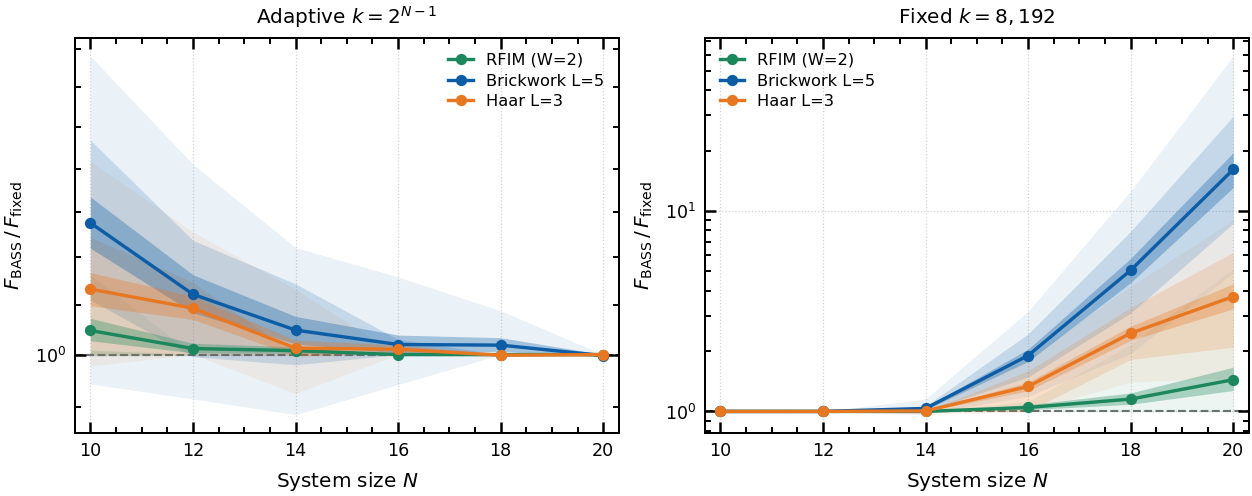


Band legend: lightest=p10-p90 · medium=IQR · darkest=CI-95 for geometric mean


In [5]:
# ── Plots (Fig 4a + 4b equivalent) ───────────────────────────────────────────
fig, (ax_adap, ax_fix) = plt.subplots(1, 2, figsize=(7.0, 2.8), constrained_layout=True)

for ax, results, title, x_vals_fn in [
    (ax_adap, adap_results, r"Adaptive $k = 2^{N-1}$", lambda r: r["N_values"]),
    (ax_fix, fix_results, rf"Fixed $k = {FIXED_K:,}$", lambda r: r["N_values"]),
]:
    legend_handles = []
    for label, res in results.items():
        c = CIRCUIT_FAMILIES[label]["color"]
        N_vals = x_vals_fn(res)

        # Central line: geometric mean of ratio
        ratio_gm = np.array(
            [res["stats"][N]["ratio"].get("geomean", np.nan) for N in N_vals]
        )

        # 3-band shading using per-N stats
        stats_by_N = {N: res["stats"][N]["ratio"] for N in N_vals}
        add_ci_bands(
            ax,
            N_vals,
            stats_by_N,
            color=c,
            use_geomean=True,
            alpha_outer=0.08,
            alpha_mid=0.17,
            alpha_inner=0.32,
        )

        valid = np.isfinite(ratio_gm) & (ratio_gm > 0)
        ax.plot(
            np.array(N_vals)[valid],
            ratio_gm[valid],
            color=c,
            marker="o",
            markersize=3.5,
            linewidth=1.35,
            zorder=5,
        )
        legend_handles.append(
            Line2D([0], [0], color=c, lw=1.35, marker="o", ms=3.5, label=label)
        )

    ax.axhline(1.0, color="#333", ls="--", lw=0.85, alpha=0.7, zorder=0)
    ax.set_yscale("log")
    ax.set_xticks(N_VALUES)
    ax.set_xlabel(r"System size $N$")
    ax.set_ylabel(r"$F_{\rm BASS}\,/\,F_{\rm fixed}$")
    ax.set_title(title, fontsize=8)
    ax.legend(handles=legend_handles, frameon=False, fontsize=6.5)
    ax.grid(which="major", ls=":", lw=0.5, alpha=0.35)
    polish_axes(ax)

save_figure(fig, FIGURE_DIR / "fig_n_scaling")
plt.show()
print("\nBand legend: lightest=p10-p90 · medium=IQR · darkest=CI-95 for geometric mean")

Saved c:\Users\karti\pyth\BASS code\tests\figures\fig_adaptive_scaling.pdf/.svg/.png


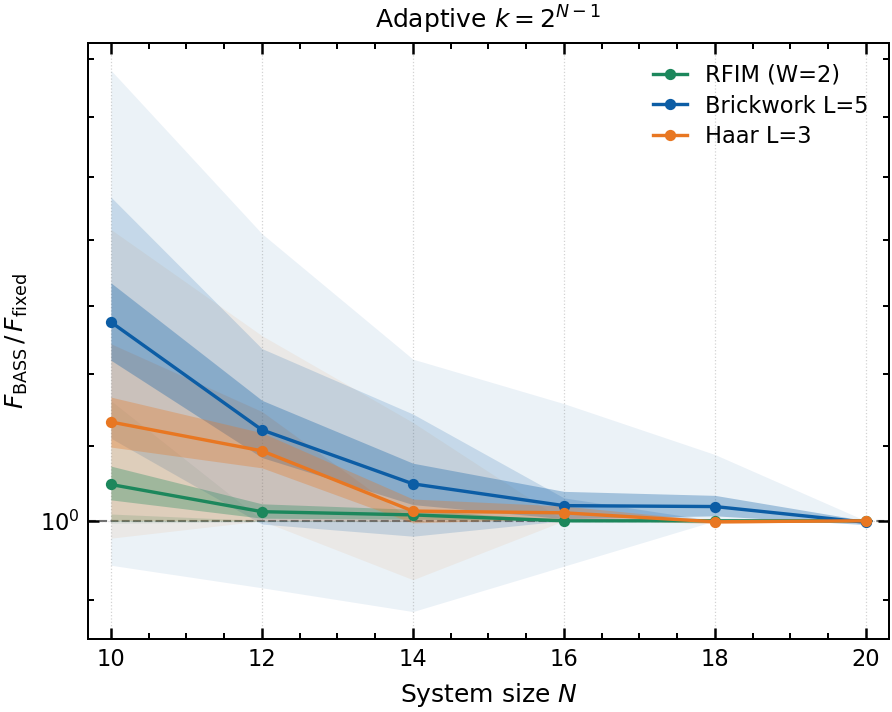

Saved c:\Users\karti\pyth\BASS code\tests\figures\fig_fixed_scaling.pdf/.svg/.png


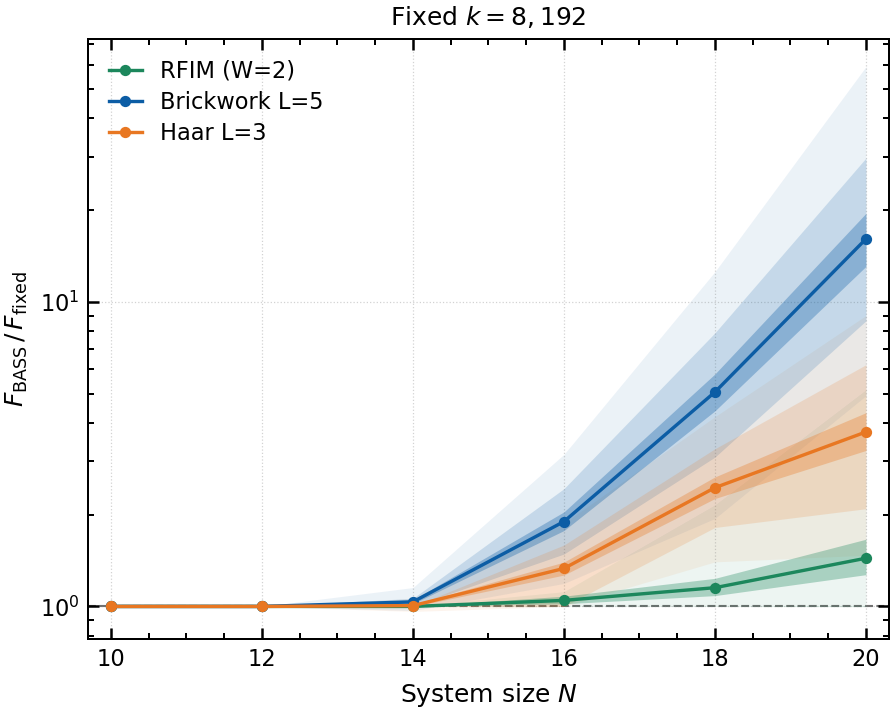


Band legend: lightest=p10-p90 · medium=IQR · darkest=CI-95 for geometric mean


In [6]:
# ── Plot 1: Adaptive scaling ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

legend_handles = []

for label, res in adap_results.items():

    c = CIRCUIT_FAMILIES[label]["color"]
    N_vals = res["N_values"]

    # Central line: geometric mean of ratio
    ratio_gm = np.array(
        [res["stats"][N]["ratio"].get("geomean", np.nan) for N in N_vals]
    )

    # 3-band shading
    stats_by_N = {N: res["stats"][N]["ratio"] for N in N_vals}

    add_ci_bands(
        ax,
        N_vals,
        stats_by_N,
        color=c,
        use_geomean=True,
        alpha_outer=0.08,
        alpha_mid=0.17,
        alpha_inner=0.32,
    )

    valid = np.isfinite(ratio_gm) & (ratio_gm > 0)

    ax.plot(
        np.array(N_vals)[valid],
        ratio_gm[valid],
        color=c,
        marker="o",
        markersize=3.5,
        linewidth=1.35,
        zorder=5,
    )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=c,
            lw=1.35,
            marker="o",
            ms=3.5,
            label=label,
        )
    )

ax.axhline(
    1.0,
    color="#333",
    ls="--",
    lw=0.85,
    alpha=0.7,
    zorder=0,
)

ax.set_yscale("log")
ax.set_xticks(N_VALUES)

ax.set_xlabel(r"System size $N$", fontsize=10)
ax.set_ylabel(r"$F_{\rm BASS}\,/\,F_{\rm fixed}$", fontsize=10)

ax.set_title(r"Adaptive $k = 2^{N-1}$", fontsize=10)

ax.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=9,
)

ax.tick_params(axis="both", labelsize=9)

ax.grid(
    which="major",
    ls=":",
    lw=0.5,
    alpha=0.35,
)

polish_axes(ax)

save_figure(fig, FIGURE_DIR / "fig_adaptive_scaling")

plt.show()


# ── Plot 2: Fixed-k scaling ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

legend_handles = []

for label, res in fix_results.items():

    c = CIRCUIT_FAMILIES[label]["color"]
    N_vals = res["N_values"]

    # Central line: geometric mean of ratio
    ratio_gm = np.array(
        [res["stats"][N]["ratio"].get("geomean", np.nan) for N in N_vals]
    )

    # 3-band shading
    stats_by_N = {N: res["stats"][N]["ratio"] for N in N_vals}

    add_ci_bands(
        ax,
        N_vals,
        stats_by_N,
        color=c,
        use_geomean=True,
        alpha_outer=0.08,
        alpha_mid=0.17,
        alpha_inner=0.32,
    )

    valid = np.isfinite(ratio_gm) & (ratio_gm > 0)

    ax.plot(
        np.array(N_vals)[valid],
        ratio_gm[valid],
        color=c,
        marker="o",
        markersize=3.5,
        linewidth=1.35,
        zorder=5,
    )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=c,
            lw=1.35,
            marker="o",
            ms=3.5,
            label=label,
        )
    )

ax.axhline(
    1.0,
    color="#333",
    ls="--",
    lw=0.85,
    alpha=0.7,
    zorder=0,
)

ax.set_yscale("log")
ax.set_xticks(N_VALUES)

ax.set_xlabel(r"System size $N$", fontsize=10)
ax.set_ylabel(r"$F_{\rm BASS}\,/\,F_{\rm fixed}$", fontsize=10)

ax.set_title(rf"Fixed $k = {FIXED_K:,}$", fontsize=10)

ax.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=9,
)

ax.tick_params(axis="both", labelsize=9)

ax.grid(
    which="major",
    ls=":",
    lw=0.5,
    alpha=0.35,
)

polish_axes(ax)

save_figure(fig, FIGURE_DIR / "fig_fixed_scaling")

plt.show()

print(
    "\nBand legend: " "lightest=p10-p90 · medium=IQR · darkest=CI-95 for geometric mean"
)